<a href="https://colab.research.google.com/github/RayyanShajahan/My-codes/blob/main/deep_learning_day_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import zipfile
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

zip_path = "/content/archive (21).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Dataset Extracted Successfully")

# Define paths and image dimensions
data_dir_base = "dataset"

# Inspect the extracted directory structure to find the actual directory containing 'yes' and 'no'
print(f"Contents of {data_dir_base}: {os.listdir(data_dir_base)}")

# Adjust data_dir to point to the correct parent directory of 'yes' and 'no'
if 'brain_tumor_dataset' in os.listdir(data_dir_base):
    data_dir = os.path.join(data_dir_base, 'brain_tumor_dataset')
else:
    data_dir = data_dir_base

print(f"Adjusted data directory: {data_dir}")

img_size = (128, 128)

# --- Data Loading and Preprocessing for Scikit-learn models ---
images = []
labels = []
class_names = ['no', 'yes'] # Assuming 'no' is 0, 'yes' is 1

# Load 'no' class images (label 0)
no_tumor_path = os.path.join(data_dir, 'no')
for img_name in os.listdir(no_tumor_path):
    img_path = os.path.join(no_tumor_path, img_name)
    try:
        img = cv2.imread(img_path)
        img = cv2.resize(img, img_size) # Resize image
        img = img / 255.0 # Normalize pixel values
        images.append(img.flatten()) # Flatten for scikit-learn models
        labels.append(0)
    except Exception as e:
        print(f"Error loading image {img_name} from 'no' class: {e}")

# Load 'yes' class images (label 1)
yes_tumor_path = os.path.join(data_dir, 'yes')
for img_name in os.listdir(yes_tumor_path):
    img_path = os.path.join(yes_tumor_path, img_name)
    try:
        img = cv2.imread(img_path)
        img = cv2.resize(img, img_size) # Resize image
        img = img / 255.0 # Normalize pixel values
        images.append(img.flatten()) # Flatten for scikit-learn models
        labels.append(1)
    except Exception as e:
        print(f"Error loading image {img_name} from 'yes' class: {e}")

X = np.array(images)
y = np.array(labels)

# Split data into training and testing sets
X_train_flat, X_test_flat, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total images loaded: {len(X)}")
print(f"Shape of training features: {X_train_flat.shape}")
print(f"Shape of testing features: {X_test_flat.shape}")
print(f"Shape of training labels: {y_train.shape}")
print(f"Shape of testing labels: {y_test.shape}")

Dataset Extracted Successfully
Contents of dataset: ['brain_tumor_dataset', 'no', 'yes']
Adjusted data directory: dataset/brain_tumor_dataset
Total images loaded: 253
Shape of training features: (202, 49152)
Shape of testing features: (51, 49152)
Shape of training labels: (202,)
Shape of testing labels: (51,)


### Logistic Regression Model

Training Logistic Regression model...
Logistic Regression training complete.

--- Logistic Regression Model Evaluation ---
Classification Report:
              precision    recall  f1-score   support

          no       0.76      0.65      0.70        20
         yes       0.79      0.87      0.83        31

    accuracy                           0.78        51
   macro avg       0.78      0.76      0.77        51
weighted avg       0.78      0.78      0.78        51

Confusion Matrix:


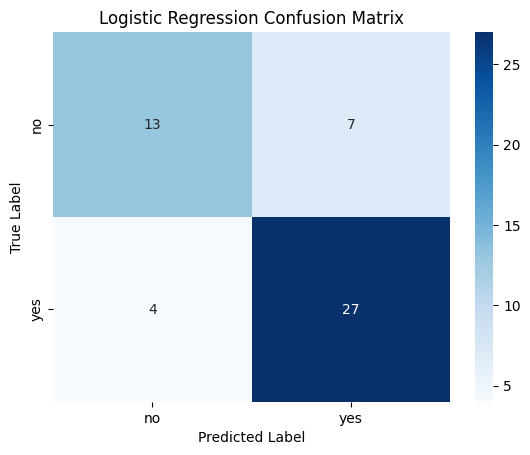

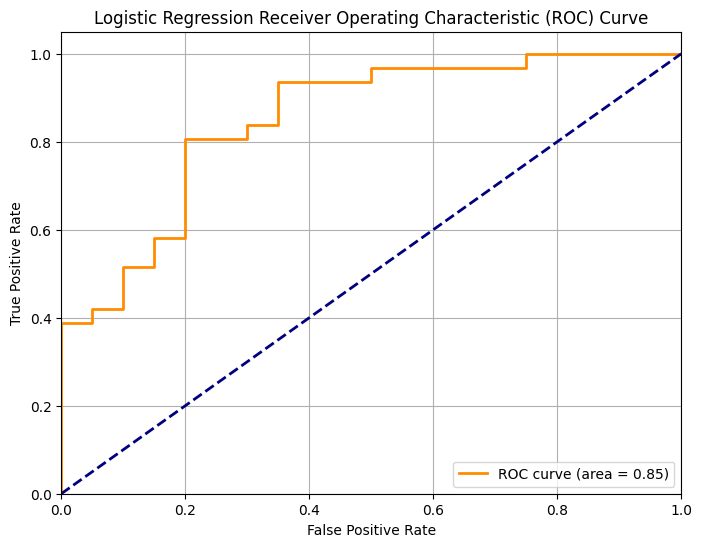

In [26]:
# Initialize and train Logistic Regression model
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)
print("Training Logistic Regression model...")
log_reg_model.fit(X_train_flat, y_train)
print("Logistic Regression training complete.")

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test_flat)
y_proba_log_reg = log_reg_model.predict_proba(X_test_flat)[:, 1] # Probability of the positive class ('yes')

# Evaluate Logistic Regression model
print("\n--- Logistic Regression Model Evaluation ---")
print("Classification Report:")
print(classification_report(y_test, y_pred_log_reg, target_names=class_names))

print("Confusion Matrix:")
conf_matrix_log_reg = confusion_matrix(y_test, y_pred_log_reg)
sns.heatmap(conf_matrix_log_reg, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

# ROC Curve for Logistic Regression
fpr_log_reg, tpr_log_reg, _ = roc_curve(y_test, y_proba_log_reg)
roc_auc_log_reg = auc(fpr_log_reg, tpr_log_reg)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log_reg, tpr_log_reg, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_log_reg:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Random Forest Model

Training Random Forest Classifier model...
Random Forest training complete.

--- Random Forest Model Evaluation ---
Classification Report:
              precision    recall  f1-score   support

          no       0.78      0.70      0.74        20
         yes       0.82      0.87      0.84        31

    accuracy                           0.80        51
   macro avg       0.80      0.79      0.79        51
weighted avg       0.80      0.80      0.80        51

Confusion Matrix:


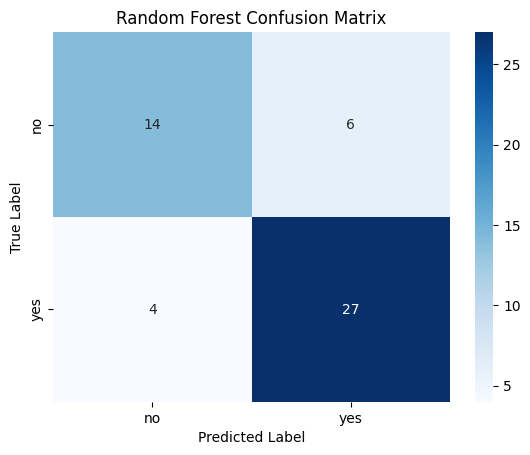

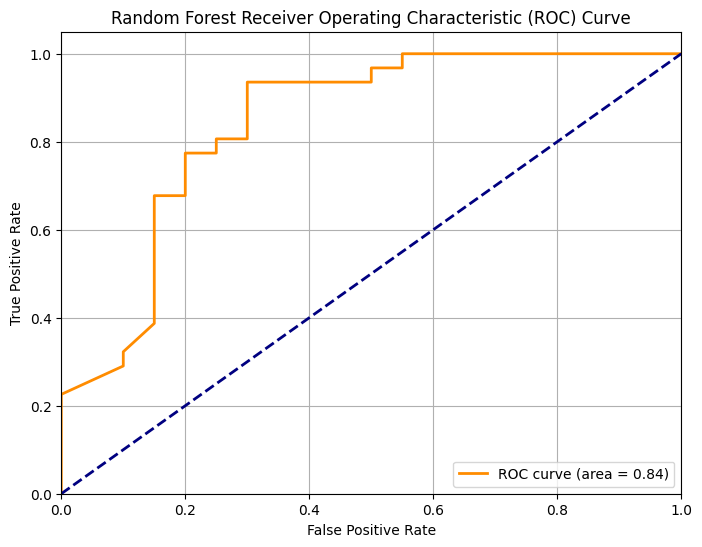

In [27]:
# Initialize and train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
print("Training Random Forest Classifier model...")
rf_model.fit(X_train_flat, y_train)
print("Random Forest training complete.")

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test_flat)
y_proba_rf = rf_model.predict_proba(X_test_flat)[:, 1] # Probability of the positive class ('yes')

# Evaluate Random Forest model
print("\n--- Random Forest Model Evaluation ---")
print("Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=class_names))

print("Confusion Matrix:")
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Random Forest Confusion Matrix')
plt.show()

# ROC Curve for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Visualizing Test Data Predictions (Logistic Regression & Random Forest)

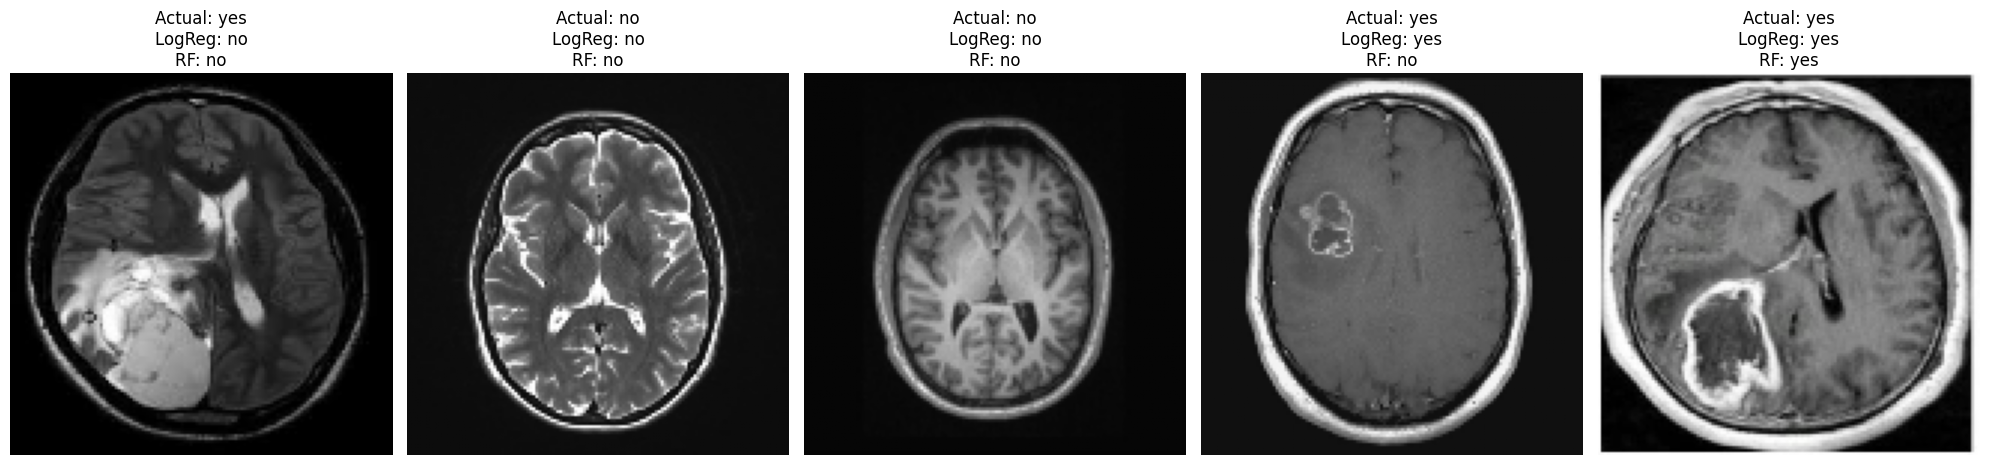

In [29]:
num_images_to_display = 5 # Display up to 5 images from the test set

plt.figure(figsize=(20, 10))

for i in range(min(num_images_to_display, len(X_test_flat))):
    # Reshape the flattened image back to its original 2D or 3D shape for display
    # Assuming original shape was (128, 128, 3) for RGB images
    image_display = X_test_flat[i].reshape(img_size[0], img_size[1], 3)

    actual_label = class_names[y_test[i]]
    predicted_log_reg = class_names[log_reg_model.predict(X_test_flat[i].reshape(1, -1))[0]]
    predicted_rf = class_names[rf_model.predict(X_test_flat[i].reshape(1, -1))[0]]

    plt.subplot(1, num_images_to_display, i + 1)
    plt.imshow(image_display)
    plt.title(f"Actual: {actual_label}\nLogReg: {predicted_log_reg}\nRF: {predicted_rf}",
              color='black') # Color can be adjusted based on prediction match
    plt.axis('off')

plt.tight_layout()
plt.show()

### Classify New Images (for Scikit-learn models)


--- Demonstrating with Logistic Regression ---

--- Classifying images in folder: /content/test using Logistic Regression ---

--- Classification Result for /content/test/scan1.jpeg ---
Predicted Probability (for 'yes'): 0.7167
Predicted Class: yes


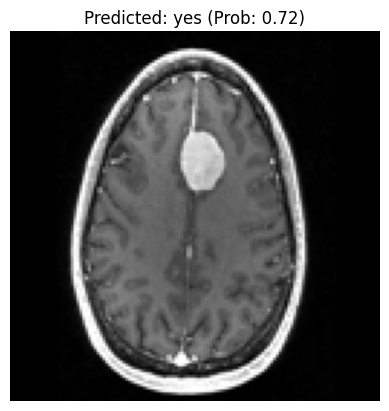


--- Demonstrating with Random Forest ---

--- Classifying images in folder: /content/test using Random Forest ---

--- Classification Result for /content/test/scan1.jpeg ---
Predicted Probability (for 'yes'): 0.3700
Predicted Class: no


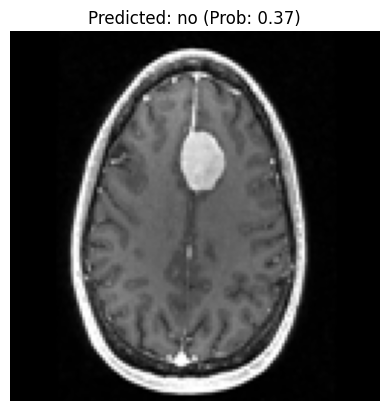


To test with your own images, please upload them to the `/content/test` folder and then re-run the last cell.


In [28]:
from PIL import Image

def classify_new_image_sklearn(image_path, model, img_size, class_names):
    try:
        img = Image.open(image_path).convert('RGB')
        img = img.resize(img_size)
        img_array = np.array(img) / 255.0 # Normalize pixel values
        img_array_flat = img_array.flatten().reshape(1, -1) # Flatten and reshape for single prediction

        prediction_proba = model.predict_proba(img_array_flat)[0, 1] # Probability of the positive class ('yes')
        predicted_class_idx = (prediction_proba > 0.5).astype(int)
        predicted_class_label = class_names[predicted_class_idx]

        print(f"\n--- Classification Result for {image_path} ---")
        print(f"Predicted Probability (for '{class_names[1]}'): {prediction_proba:.4f}")
        print(f"Predicted Class: {predicted_class_label}")

        plt.imshow(img)
        plt.title(f"Predicted: {predicted_class_label} (Prob: {prediction_proba:.2f})")
        plt.axis('off')
        plt.show()
        return predicted_class_label, prediction_proba
    except FileNotFoundError:
        print(f"Error: Image file not found at {image_path}")
        return None, None
    except Exception as e:
        print(f"An error occurred during classification: {e}")
        return None, None

# User specified folder for new images
test_image_folder = "/content/test"

def classify_images_in_folder_sklearn(folder_path, model_name, model_obj, img_size, class_names):
    print(f"\n--- Classifying images in folder: {folder_path} using {model_name} ---")
    image_files = []
    for ext in ['*.jpg', '*.jpeg', '*.png']:
        image_files.extend(glob.glob(os.path.join(folder_path, ext)))

    if not image_files:
        print(f"No image files found in {folder_path} (supported formats: .jpg, .jpeg, .png).")
        return

    for img_path in image_files:
        classify_new_image_sklearn(img_path, model_obj, img_size, class_names)

# Ensure the folder exists, create it if it doesn't
if not os.path.exists(test_image_folder):
    os.makedirs(test_image_folder)
    print(f"Created folder: {test_image_folder}. Please upload your test images here.")

print("\n--- Demonstrating with Logistic Regression ---")
classify_images_in_folder_sklearn(test_image_folder, "Logistic Regression", log_reg_model, img_size, class_names)

print("\n--- Demonstrating with Random Forest ---")
classify_images_in_folder_sklearn(test_image_folder, "Random Forest", rf_model, img_size, class_names)

